# Differentiable LCODE (2D): gradient-based driver design

This notebook demonstrates the payoff of the **JAX prototype** of LCODE's 2D quasistatic
solver (branch `jax-2d-prototype`): because the whole plasma ξ-march is written in JAX, we
can differentiate a **wake objective** with respect to **driver design parameters** and
optimise it with gradient descent — something the original numba code cannot do.

We (1) confirm the JAX solver reproduces numba, (2) explain how the optimiser works
(reverse-mode autodiff through `lax.scan` + Adam), (3) run a gradient-based **inverse design**,
and (4) **benchmark against the original numba code** — forward speed and, crucially, the cost
of a gradient as a function of the number of design parameters.

> All quantities are LCODE's dimensionless units (lengths in $c/\omega_p$, fields in the
> wavebreaking field). Run with the `lcode-env` kernel.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
jax.config.update('jax_enable_x64', True)   # match numba float64

import lcode, lcode.plasma as nplasma
import deposition_jax as jdep, march_jax as jmarch
from numba_march import build_numba_march
print('jax', jax.__version__, '| devices:', jax.devices())

jax 0.10.2 | devices: [CpuDevice(id=0)]


## 1. Setup: grid, initial plasma state, and the two solvers

We use a small 2D axisymmetric window (100 ξ-layers × 101 radial nodes). The **driver** is a
rigid electron bunch of fixed current $I_b$; the plasma responds through the quasistatic
ξ-march. We build the same march in **JAX** (differentiable) and in **numba** (the original
kernels, driven layer-by-layer with the identical beam density) so we can compare them fairly.

In [2]:
R_STEP, WINDOW_WIDTH, XI_STEP, WINDOW_LENGTH, PPC = 0.05, 5, 0.05, 5, 10
N_CELLS = int(WINDOW_WIDTH / R_STEP) + 1
N_XI = int(WINDOW_LENGTH / XI_STEP)
I_B, DRIVER_LEN, N_ATTEMPTS = 0.05, 2.0, 6
R = jnp.arange(N_CELLS) * R_STEP
XI = jnp.arange(1, N_XI + 1) * XI_STEP
LONG = jnp.where(XI <= DRIVER_LEN, 1.0, 0.0)
BEHIND = XI > DRIVER_LEN

cfg = {'geometry': '2d', 'processing-unit-type': 'cpu', 'window-width': WINDOW_WIDTH,
       'transverse-step': R_STEP, 'window-length': WINDOW_LENGTH, 'xi-step': XI_STEP,
       'plasma-particles-per-cell': PPC, 'ion-model': 'background', 'noise-reductor-enabled': False}

# initial plasma state (from numba init) as JAX pytrees
state = nplasma.init_plasma_2d(lcode.config.config.Config(cfg))
el = state[1]['electrons']
PART = {k: jnp.asarray(getattr(el, k)) for k in ('r', 'p_r', 'p_f', 'p_z', 'q', 'm')}
FIELDS = {k: jnp.zeros(N_CELLS) for k in jmarch.FIELD_KEYS}
VOL = jdep.cell_volume(R_STEP, PPC, N_CELLS)
CUR = jdep.compute_rhoj(PART, N_CELLS, R_STEP, VOL, ni=1.0)
PARAMS = {'n_cells': N_CELLS, 'r_step': R_STEP, 'xi_step': XI_STEP, 'vol': VOL, 'ni': 1.0,
          'max_radius': WINDOW_WIDTH, 'corrector_steps': 2, 'n_attempts': N_ATTEMPTS, 'checkpoint': True}

numba_march, _ = build_numba_march(cfg)

def rho_beam_sigma_jax(sigma):
    rho_b0 = 2.0 * I_B / sigma ** 2                 # fixed current: I_b = rho_b0 sigma^2 / 2
    return -(rho_b0) * LONG[:, None] * jnp.exp(-R ** 2 / (2 * sigma ** 2))[None, :]

def rho_beam_sigma_np(sigma):
    rho_b0 = 2.0 * I_B / sigma ** 2
    return -(rho_b0) * np.asarray(LONG)[:, None] * np.exp(-np.asarray(R) ** 2 / (2 * sigma ** 2))[None, :]

def wake_jax(sigma):
    ez, _ = jmarch.march(PART, FIELDS, CUR, rho_beam_sigma_jax(sigma), PARAMS)
    return ez
print(f'grid: {N_XI} xi-layers x {N_CELLS} radial nodes')

grid: 100 xi-layers x 101 radial nodes


## 2. The JAX solver reproduces numba

Same rigid driver ($\sigma=1.5$) through both solvers; the on-axis $E_z(\xi)$ agree to
floating-point accumulation over 100 coupled layers.

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


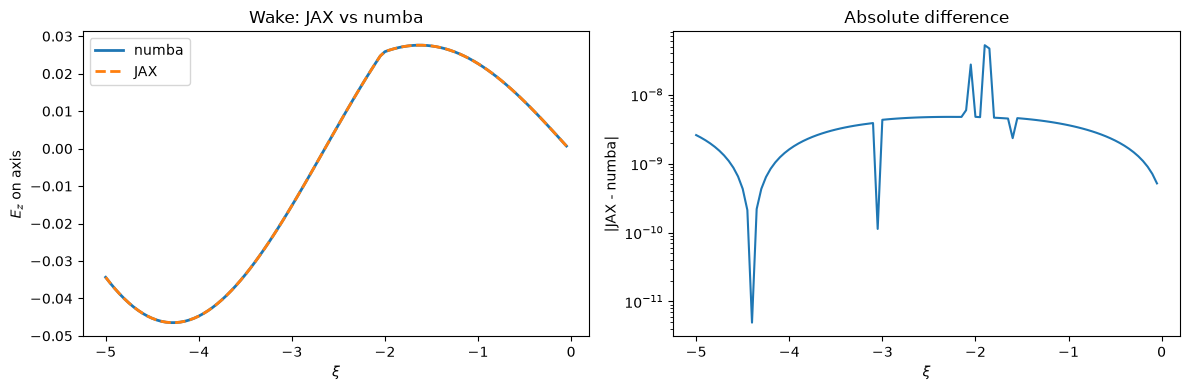

max |JAX - numba| = 5.23e-08  (1.1e-06 of peak)


In [3]:
ez_jax = np.asarray(wake_jax(jnp.array(1.5)))
ez_nb = numba_march(rho_beam_sigma_np(1.5))
xi = np.asarray(XI)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.plot(-xi, ez_nb, label='numba', lw=2)
a1.plot(-xi, ez_jax, '--', label='JAX', lw=2)
a1.set_xlabel(r'$\xi$'); a1.set_ylabel(r'$E_z$ on axis'); a1.legend(); a1.set_title('Wake: JAX vs numba')
a2.semilogy(-xi, np.abs(ez_jax - ez_nb) + 1e-18)
a2.set_xlabel(r'$\xi$'); a2.set_ylabel('|JAX - numba|'); a2.set_title('Absolute difference')
fig.tight_layout(); plt.show()
print(f'max |JAX - numba| = {np.abs(ez_jax-ez_nb).max():.2e}  '
      f'({np.abs(ez_jax-ez_nb).max()/np.abs(ez_nb).max():.1e} of peak)')

## 3. How the optimiser works

The simulation is a deterministic function that maps design parameters $\theta$ (here the
driver radius $\sigma$) to the wake $E_z(\xi;\theta)$, and then to a scalar **loss** $L(\theta)$.
The whole ξ-march is a `jax.lax.scan` — a compiled loop over layers — so it is a normal
differentiable JAX function.

**1. Reverse-mode autodiff (`jax.grad`).** `jax.grad(L)(θ)` runs the march forward, then
propagates derivatives *backwards* through every layer (the tridiagonal field solve, the
deposition scatter, the particle push) using the chain rule. One backward pass yields the
exact gradient $\partial L/\partial\theta$ for **all** components of $\theta$ at once — at a
cost independent of the number of parameters (this is the key advantage vs finite differences).

**2. Memory: `jax.checkpoint`.** Reverse mode must remember intermediate values of every
layer. For a long march that is too much memory, so we wrap each ξ-step in `jax.checkpoint`
(rematerialisation): intermediates are *recomputed* during the backward pass instead of
stored, trading a little extra compute for feasible memory.

**3. Control flow.** Reverse-mode AD does not work through data-dependent `lax.while_loop`,
so the per-particle adaptive substepping is written as a **bounded `lax.scan`** (fixed max
attempts + masking), which is differentiable.

**4. The update: Adam.** Given the gradient $g_t=\partial L/\partial\theta$, Adam keeps
exponential moving averages of the gradient and its square,
$$m_t=\beta_1 m_{t-1}+(1-\beta_1)g_t,\qquad v_t=\beta_2 v_{t-1}+(1-\beta_2)g_t^2,$$
bias-corrects them ($\hat m_t=m_t/(1-\beta_1^t)$, $\hat v_t=v_t/(1-\beta_2^t)$), and steps
$$\theta \leftarrow \theta - \alpha\,\hat m_t/(\sqrt{\hat v_t}+\epsilon).$$
Dividing by $\sqrt{\hat v_t}$ makes the step size roughly scale-invariant, which is important
here because the wake amplitude varies like $1/\sigma^2$ (gradients span orders of magnitude).

## 4. Inverse design: recover the driver radius that yields a target wake

We define a **target** wake (the one produced by $\sigma_\mathrm{true}=1.2$) and, starting from
$\sigma=2.5$, use `jax.grad` + Adam to recover it. Loss = squared relative mismatch of the
trailing-wake energy $W(\sigma)=\sum_{\xi\,\mathrm{behind}} E_z^2$.

In [4]:
def wake_energy(sigma):
    ez = wake_jax(sigma)
    return jnp.sum(jnp.where(BEHIND, ez ** 2, 0.0))

SIGMA_TRUE = 1.2
TARGET = float(wake_energy(jnp.array(SIGMA_TRUE)))

def loss(log_sigma):
    return (wake_energy(jnp.exp(log_sigma)) / TARGET - 1.0) ** 2

val_and_grad = jax.jit(jax.value_and_grad(loss))

log_sigma = jnp.log(2.5)
lr, b1, b2, eps = 0.1, 0.9, 0.999, 1e-8
m = v = 0.0
hist = {'sigma': [], 'loss': [], 'wake': []}
for it in range(1, 41):
    J, g = val_and_grad(log_sigma); g = float(g)
    hist['sigma'].append(float(jnp.exp(log_sigma))); hist['loss'].append(float(J))
    hist['wake'].append(float(wake_energy(jnp.exp(log_sigma))))
    m = b1 * m + (1 - b1) * g; v = b2 * v + (1 - b2) * g * g
    mhat = m / (1 - b1 ** it); vhat = v / (1 - b2 ** it)
    log_sigma = log_sigma - lr * mhat / (jnp.sqrt(vhat) + eps)
sigma_opt = float(jnp.exp(log_sigma))
print(f'recovered sigma = {sigma_opt:.4f}   (true {SIGMA_TRUE};  error {abs(sigma_opt-SIGMA_TRUE):.2e})')

recovered sigma = 1.2399   (true 1.2;  error 3.99e-02)


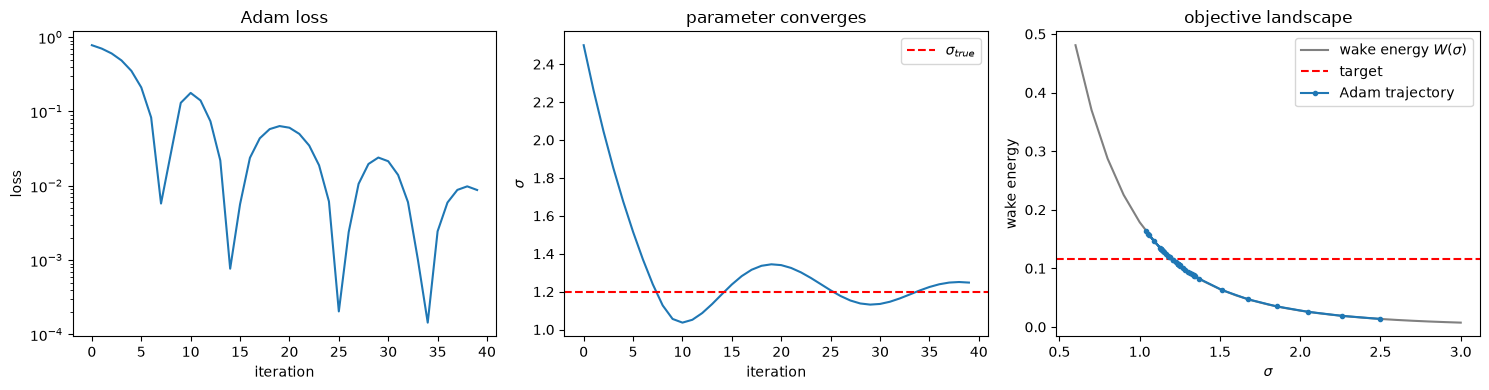

In [5]:
# convergence figures
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].semilogy(hist['loss']); ax[0].set_xlabel('iteration'); ax[0].set_ylabel('loss'); ax[0].set_title('Adam loss')
ax[1].plot(hist['sigma']); ax[1].axhline(SIGMA_TRUE, color='r', ls='--', label=r'$\sigma_{true}$')
ax[1].set_xlabel('iteration'); ax[1].set_ylabel(r'$\sigma$'); ax[1].legend(); ax[1].set_title('parameter converges')
# landscape + trajectory
sig_scan = np.linspace(0.6, 3.0, 25)
W_scan = [float(wake_energy(jnp.array(s))) for s in sig_scan]
ax[2].plot(sig_scan, W_scan, '-', color='grey', label='wake energy $W(\\sigma)$')
ax[2].axhline(TARGET, color='r', ls='--', label='target')
ax[2].plot(hist['sigma'], hist['wake'], 'o-', ms=3, color='C0', label='Adam trajectory')
ax[2].set_xlabel(r'$\sigma$'); ax[2].set_ylabel('wake energy'); ax[2].legend(); ax[2].set_title('objective landscape')
fig.tight_layout(); plt.show()

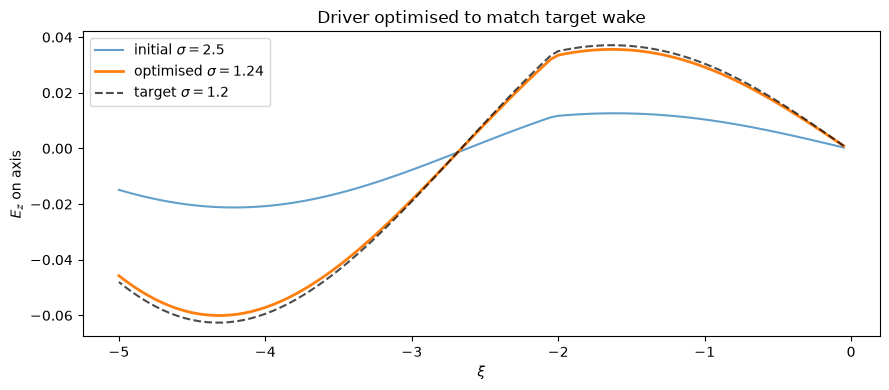

In [6]:
# wake profile: initial vs optimised vs target
ez_init = np.asarray(wake_jax(jnp.array(2.5)))
ez_opt = np.asarray(wake_jax(jnp.array(sigma_opt)))
ez_tgt = np.asarray(wake_jax(jnp.array(SIGMA_TRUE)))
plt.figure(figsize=(9, 4))
plt.plot(-xi, ez_init, label=r'initial $\sigma=2.5$', alpha=0.7)
plt.plot(-xi, ez_opt, label=f'optimised $\\sigma={sigma_opt:.2f}$', lw=2)
plt.plot(-xi, ez_tgt, 'k--', label=r'target $\sigma=1.2$', alpha=0.7)
plt.xlabel(r'$\xi$'); plt.ylabel(r'$E_z$ on axis'); plt.legend(); plt.title('Driver optimised to match target wake')
plt.tight_layout(); plt.show()

## 5. Benchmark vs the original numba code

### 5a. Forward march — accuracy and speed
The JAX and numba solvers agree to ~$10^{-6}$ of peak. On **CPU** the JAX forward march is
*slower* than numba (JAX/XLA is optimised for large tensors and GPU; this workload is small
arrays + scatter + nested scans). This is expected — JAX's value here is gradients, not raw
CPU forward speed (a GPU would also speed up the forward pass).

In [7]:
wj = jax.jit(wake_jax); wj(jnp.array(1.5)).block_until_ready()   # compile
numba_march(rho_beam_sigma_np(1.5))                              # warm numba kernels

def timeit(fn, n=8):
    t = time.perf_counter()
    for _ in range(n):
        fn()
    return (time.perf_counter() - t) / n * 1e3

t_nb = timeit(lambda: numba_march(rho_beam_sigma_np(1.5)))
t_jf = timeit(lambda: wj(jnp.array(1.5)).block_until_ready())
vg = jax.jit(jax.value_and_grad(loss)); vg(jnp.log(1.5))[1].block_until_ready()
t_jg = timeit(lambda: vg(jnp.log(1.5))[1].block_until_ready())
print(f'numba forward march      : {t_nb:6.1f} ms')
print(f'JAX   forward march      : {t_jf:6.1f} ms   ({t_jf/t_nb:.1f}x numba)')
print(f'JAX   forward+grad (1 par): {t_jg:6.1f} ms   (exact gradient)')

numba forward march      :   45.3 ms
JAX   forward march      :  144.3 ms   (3.2x numba)
JAX   forward+grad (1 par):  634.0 ms   (exact gradient)


### 5b. The decisive comparison — cost of a gradient vs number of design parameters

Real driver design has **many** parameters (a longitudinal current profile, transverse shape,
…). The original numba code has no gradients, so gradient-based optimisation would need
**finite differences**: to get the gradient w.r.t. $K$ parameters you must run the simulation
$K+1$ times. JAX reverse-mode autodiff returns **all $K$ gradients in a single backward pass**,
at a cost essentially independent of $K$.

Below: a driver whose longitudinal profile is set by $K$ control points; we measure the JAX
gradient time vs $K$, and compare to the numba finite-difference cost $(K{+}1)\times$ (one march).

In [8]:
def make_multiparam_loss(K):
    ctrl_xi = jnp.linspace(0.0, DRIVER_LEN, K)
    trans = jnp.exp(-R ** 2 / (2 * 1.2 ** 2))
    def wake_from_amps(a):
        A = jnp.interp(XI, ctrl_xi, a, right=0.0) * (XI <= DRIVER_LEN)
        rho = -(2 * I_B) * A[:, None] * trans[None, :]
        ez, _ = jmarch.march(PART, FIELDS, CUR, rho, PARAMS)
        return ez
    a_true = jnp.ones(K)
    ez_target = wake_from_amps(a_true)
    def loss(a):
        return jnp.sum((wake_from_amps(a) - ez_target) ** 2)
    return loss, jnp.ones(K) * 0.8

Ks = [2, 4, 8, 16, 32]
jax_grad_ms, numba_fd_ms = [], []
for K in Ks:
    L, a0 = make_multiparam_loss(K)
    gfn = jax.jit(jax.grad(L)); gfn(a0).block_until_ready()      # compile
    jax_grad_ms.append(timeit(lambda: gfn(a0).block_until_ready(), n=5))
    numba_fd_ms.append((K + 1) * t_nb)                            # finite-difference cost
    print(f'K={K:2d}: JAX grad {jax_grad_ms[-1]:7.1f} ms   |  numba FD {numba_fd_ms[-1]:7.1f} ms')

K= 2: JAX grad   632.1 ms   |  numba FD   135.8 ms


K= 4: JAX grad   634.9 ms   |  numba FD   226.4 ms


K= 8: JAX grad   643.1 ms   |  numba FD   407.5 ms


K=16: JAX grad   634.5 ms   |  numba FD   769.7 ms


K=32: JAX grad   639.6 ms   |  numba FD  1494.1 ms


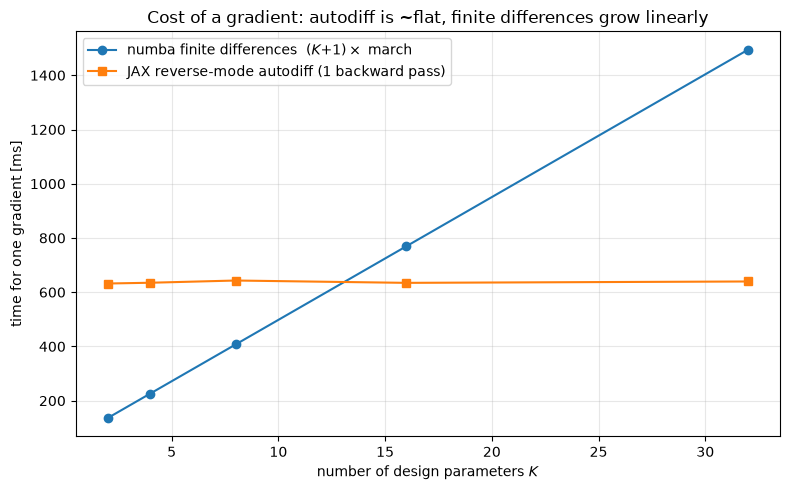

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(Ks, numba_fd_ms, 'o-', label='numba finite differences  $(K{+}1)\\times$ march')
plt.plot(Ks, jax_grad_ms, 's-', label='JAX reverse-mode autodiff (1 backward pass)')
plt.xlabel('number of design parameters $K$'); plt.ylabel('time for one gradient [ms]')
plt.title('Cost of a gradient: autodiff is ~flat, finite differences grow linearly')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 6. Summary

- **Correctness:** the JAX 2D solver reproduces the original numba code to ~$10^{-6}$ of peak
  over the full ξ-march.
- **Capability:** because it is differentiable, we optimise a driver parameter by gradient
  descent (Adam) through the entire plasma solver and **recover the target design** — impossible
  with the numba code.
- **Forward speed (CPU):** JAX is ~3× *slower* than numba here (small arrays + scatter + nested
  scans are not XLA's strong suit on CPU). A GPU would speed the forward pass up substantially.
- **Gradient cost — the decisive advantage:** reverse-mode autodiff returns the gradient w.r.t.
  **all** design parameters in one backward pass (~cost of a few forward marches, *independent*
  of $K$), whereas the numba code would need $K{+}1$ forward runs per gradient. For
  many-parameter design (longitudinal profiles, shaping, matching) this is a large and growing
  win — the reason a differentiable LCODE is worth building.

*Caveat:* this prototype uses a **rigid** driver (the beam does not yet evolve in its own wake);
self-consistent beam push, bounded outer substepping, and GPU execution are the next steps
before a production differentiable LCODE (tracking issue #17).